# Tahap 1: Preprocessing Data Beras Medium


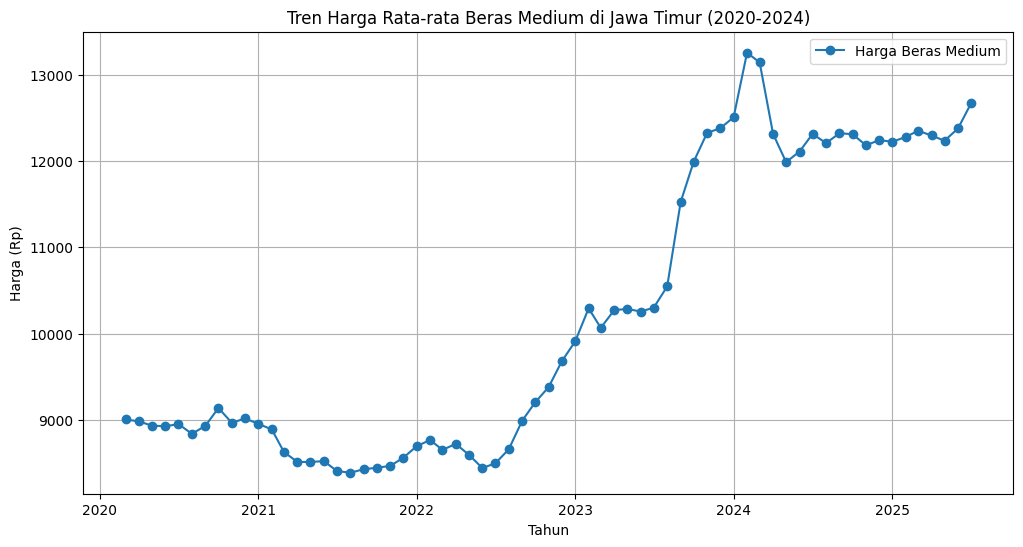

,periode_update,jumlah,lag_1,lag_2
2,2020-03-01,9007.228571,8832.633333,8992.485714
3,2020-04-01,8981.800000,9007.228571,8832.633333
4,2020-05-01,8934.285714,8981.800000,9007.228571
5,2020-06-01,8926.457143,8934.285714,8981.800000
6,2020-07-01,8952.060606,8926.457143,8934.285714


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Dataset
# Membaca data mentah dari file CSV
df = pd.read_csv('harga_pertanian.csv')

# 2. Filtering Komoditas & Pembersihan Data
df = df[(df['kategori'] == 'BERAS MEDIUM') & (df['jumlah'] > 0)]

# 3. Konversi Tipe Data Waktu
df['periode_update'] = pd.to_datetime(df['periode_update'])

# 4. Agregasi Data (Rata-rata Jawa Timur per Bulan)
df_monthly = df.groupby('periode_update')['jumlah'].mean().reset_index()
df_monthly = df_monthly.sort_values('periode_update')

# 5. Feature Engineering (Lag Features)
df_monthly['lag_1'] = df_monthly['jumlah'].shift(1)
df_monthly['lag_2'] = df_monthly['jumlah'].shift(2)

# 6. Menghapus Data Kosong (akibat proses shifting)
df_monthly = df_monthly.dropna()

# 7. Visualisasi Tren Awal
plt.figure(figsize=(12,6))
plt.plot(df_monthly['periode_update'], df_monthly['jumlah'], marker='o', label='Harga Beras Medium')
plt.title('Tren Harga Rata-rata Beras Medium di Jawa Timur (2020-2024)')
plt.xlabel('Tahun')
plt.ylabel('Harga (Rp)')
plt.legend()
plt.grid(True)
plt.show()

# 8. Simpan Hasil 
df_monthly.to_csv('beras_medium_monthly.csv', index=False)
df_monthly.head()

In [2]:
from sklearn.preprocessing import MinMaxScaler

# 9. Normalisasi Data (Scaling)
# Menentukan Fitur (X) dan Target (y)
X = df_monthly[['lag_1', 'lag_2']].values
y = df_monthly['jumlah'].values.reshape(-1, 1)

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# 10. Simpan Hasil Ter-scaling ke CSV
df_scaled = pd.DataFrame(X_scaled, columns=['lag_1_scaled', 'lag_2_scaled'])
df_scaled['jumlah_scaled'] = y_scaled.flatten()

df_scaled.to_csv('beras_scaled.csv', index=False)
print("Data ter-scaling berhasil disimpan ke 'beras_scaled.csv'")
df_scaled.head()

Data ter-scaling berhasil disimpan ke 'beras_scaled.csv'


,lag_1_scaled,lag_2_scaled,jumlah_scaled
0,0.091316,0.124159,0.127188
1,0.127188,0.091316,0.121963
2,0.121963,0.127188,0.112201
3,0.112201,0.121963,0.110593
4,0.110593,0.112201,0.115853
